# Exploratory Data Analysis: Predicting Outpatient No-Shows

## 1. Executive Summary & Clinical Context
Missed clinical appointments (no-shows) represent a major operational bottleneck in healthcare, resulting in underutilized resources, revenue loss, and delayed care for other patients. 

**Objective:** To analyze the operational and demographic determinants of appointment adherence and identify risk factors associated with no-shows. This exploratory analysis serves as the foundation for developing a predictive classification model to enable targeted operational interventions, such as automated patient reminders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

## 2. Data Ingestion
Importing the historical appointment records. The dataset utilized is the Medical Appointment No Shows dataset, comprising over 100,000 outpatient appointments.

In [2]:
# Ingest raw dataset
file_path = '../data/raw/KaggleV2-May-2016.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Data successfully ingested. Shape: {df.shape[0]} records, {df.shape[1]} features.")
except FileNotFoundError:
    print(f"Error: Path {file_path} not found.")

Data successfully ingested. Shape: 110527 records, 14 features.


## 3. Dataset Structure and Integrity
Assessing data types, structural integrity, and identifying potential missing values or anomalies requiring remediation.

In [3]:
# Display dataset architecture
display(df.head())

# Assess data types and missing values
print("\n--- Structural Overview ---")
df.info()

# Baseline statistical distribution
print("\n--- Statistical Distribution ---")
display(df.describe())

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No



--- Structural Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.6 MB

--- Statistical Distribution ---


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


## 4. Data Cleaning & Clinical Feature Engineering
Raw operational data often requires transformation for machine learning applications. From a clinical logistics perspective, the "Lead Time" (the interval between scheduling an appointment and the actual visit) is a critical determinant of patient attendance.

In [4]:
# 1. Standardize nomenclature for consistency
df.rename(columns={'Hipertension': 'Hypertension',
                   'Handcap': 'Handicap',
                   'No-show': 'No_Show'}, inplace=True)

# 2. Parse temporal features
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay']).dt.date
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.date

# 3. Feature Engineering: Derive operational 'Lead Time'
df['LeadDays'] = (df['AppointmentDay'] - df['ScheduledDay']).apply(lambda x: x.days)

# 4. Filter anomalous records (e.g., negative lead times or data entry errors in age)
df = df[(df['LeadDays'] >= 0) & (df['Age'] >= 0)]

print(f"Dataset shape post-cleaning: {df.shape}")

Dataset shape post-cleaning: (110521, 15)


## 5. Exploratory Data Analysis (EDA)

### 5.1 Baseline No-Show Distribution
Establishing the baseline metric to understand the degree of class imbalance in the target variable.

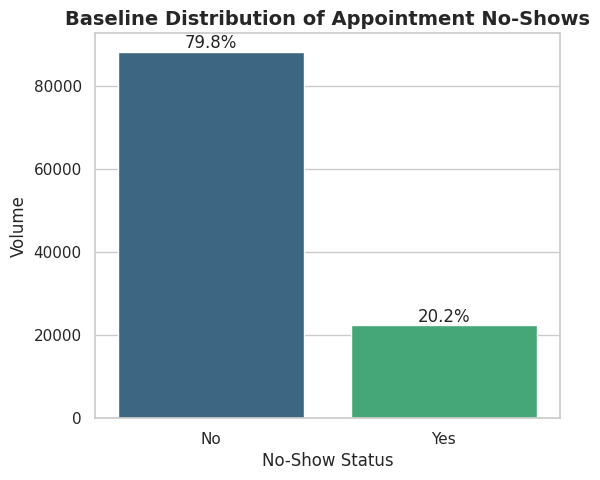

In [5]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='No_Show', data=df, palette='viridis')
plt.title('Baseline Distribution of Appointment No-Shows', fontsize=14, fontweight='bold')
plt.xlabel('No-Show Status', fontsize=12)
plt.ylabel('Volume', fontsize=12)

# Annotate proportions
total_records = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_records:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.show()

### 5.2 Evaluating Operational Determinants
Analyzing how operational factors, specifically Lead Time and automated SMS interventions, correlate with attendance rates.

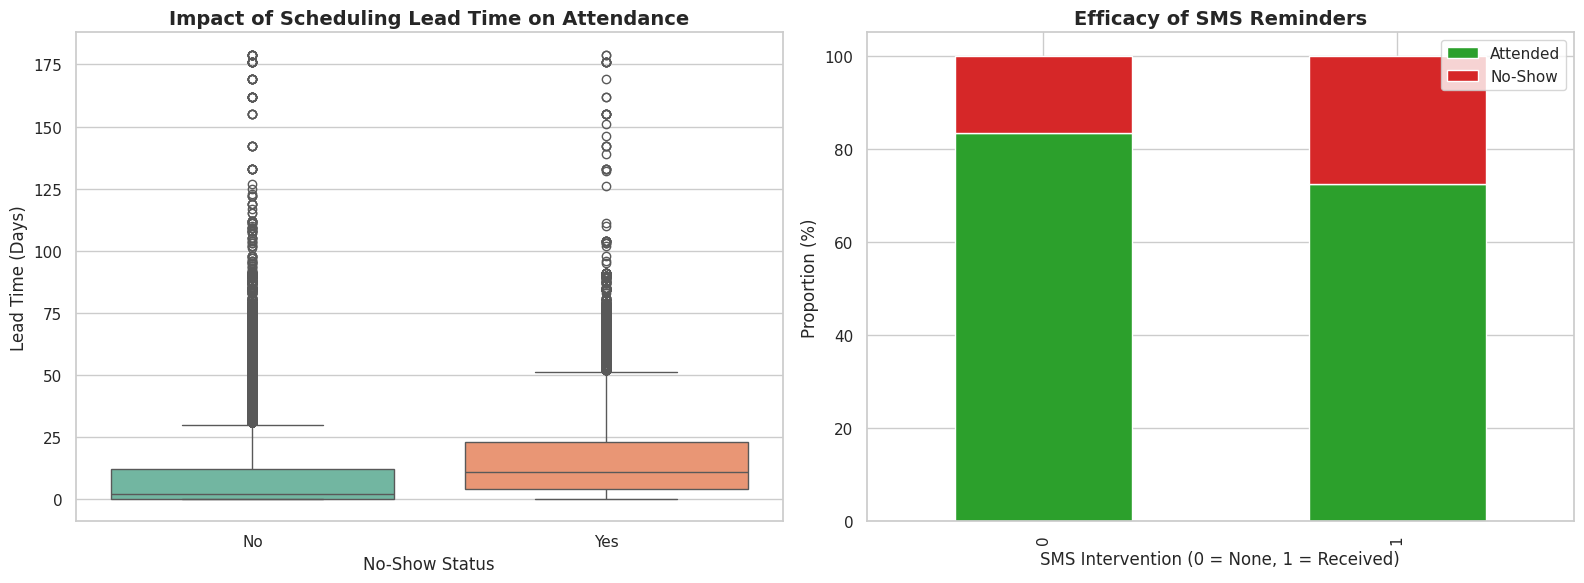

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Analysis 1: Lead Time Variance
sns.boxplot(x='No_Show', y='LeadDays', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Impact of Scheduling Lead Time on Attendance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('No-Show Status', fontsize=12)
axes[0].set_ylabel('Lead Time (Days)', fontsize=12)

# Analysis 2: SMS Intervention Efficacy
sms_impact = df.groupby('SMS_received')['No_Show'].value_counts(normalize=True).unstack() * 100
sms_impact.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ca02c', '#d62728'])
axes[1].set_title('Efficacy of SMS Reminders', fontsize=14, fontweight='bold')
axes[1].set_xlabel('SMS Intervention (0 = None, 1 = Received)', fontsize=12)
axes[1].set_ylabel('Proportion (%)', fontsize=12)
axes[1].legend(['Attended', 'No-Show'], loc='upper right')

plt.tight_layout()
plt.show()

## 6. Key Findings & Next Steps

**Actionable Insights:**
1. **Target Variable Imbalance:** The baseline no-show rate is approximately 20%. Strategies such as class weighting or SMOTE will be required during model training to address this imbalance.
2. **Operational Correlation:** Patients with extended lead times demonstrate a higher propensity for missing appointments, validating lead time as a high-value predictor.
3. **Intervention Analysis:** SMS reminders alone do not guarantee attendance, indicating that blanket SMS strategies may be inefficient. Interventions should be targeted based on a multidimensional risk profile.

**Next Phase (02_model_training):**
Transitioning to the predictive phase. Categorical variables will be encoded, numerical features scaled, and a classification algorithm will be trained to output a probabilistic risk score for each patient appointment.